In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers





In [ ]:
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
df = pd.read_csv('telecom_churn.csv')

In [ ]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
df.shape

(3333, 21)

2.Data Preprocessing anf feature extraction

In [ ]:
if 'phone number' in df.columns: df = df.drop('phone number', axis=1)


df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})
df['churn'] = df['churn'].astype(int)


df = pd.get_dummies(df, columns=['state'], prefix='state')


df['total_minutes'] = df['total day minutes'] + df['total eve minutes'] + df['total night minutes'] + df['total intl minutes']
df['total_calls']   = df['total day calls'] + df['total eve calls'] + df['total night calls'] + df['total intl calls']
df['total_charge']  = df['total day charge'] + df['total eve charge'] + df['total night charge'] + df['total intl charge']
df['cost_per_minute'] = df['total_charge'] / df['total_minutes'].replace(0, 1)

3. Split Data

In [ ]:
# --- 3. SPLIT DATA ---
X = df.drop('churn', axis=1).values
y = df['churn'].values

# Stratify(to ensure churners are in both sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

 4. OVERSAMPLING (Only on Training Data)


In [ ]:
train_df = pd.DataFrame(X_train)
train_df['churn'] = y_train

# Separate
majority = train_df[train_df['churn'] == 0]
minority = train_df[train_df['churn'] == 1]

# Upsample Minority to match Majority
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
upsampled_df = pd.concat([majority, minority_upsampled])

# Split back
X_train_final = upsampled_df.drop('churn', axis=1).values
y_train_final = upsampled_df['churn'].values

5. SCALING

In [ ]:
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_test = scaler.transform(X_test)

6.MODEL DEFINITION

In [ ]:
model = keras.Sequential([
    # Reduced neurons (32) + L2 Regularization + High Dropout (0.4)
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(X_train_final.shape[1],)),
    layers.Dropout(0.4),

    layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Stop training if validation loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

 7. TRAIN

In [ ]:
print("Training with Early Stopping...")
history = model.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Training with Early Stopping...
Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5239 - loss: 0.9472 - val_accuracy: 0.7031 - val_loss: 0.6718
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5843 - loss: 0.7282 - val_accuracy: 0.7676 - val_loss: 0.6105
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6482 - loss: 0.6525 - val_accuracy: 0.7766 - val_loss: 0.5659
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6986 - loss: 0.6118 - val_accuracy: 0.7886 - val_loss: 0.5311
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7513 - loss: 0.5545 - val_accuracy: 0.7946 - val_loss: 0.5018
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7819 - loss: 0.5115 - val_accuracy: 0.7991 - val_loss: 0.4792
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7952 - loss: 0.4908 - val_accuracy: 0.8051 - val_loss: 0.4546
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8068 -

8. Results


In [ ]:

print(f"\nFinal Train Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Test Accuracy:  {history.history['val_accuracy'][-1]*100:.2f}%")

print("\n--- Final Report (Threshold 0.4) ---")
# 0.4 threshold to catch more churners
y_pred = (model.predict(X_test) > 0.4).astype(int)
print(classification_report(y_test, y_pred))


Final Train Accuracy: 91.97%
Final Test Accuracy:  86.06%

--- Final Report (Threshold 0.4) ---
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       570
           1       0.49      0.73      0.59        97

    accuracy                           0.85       667
   macro avg       0.72      0.80      0.75       667
weighted avg       0.88      0.85      0.86       667



9. PLOTTING

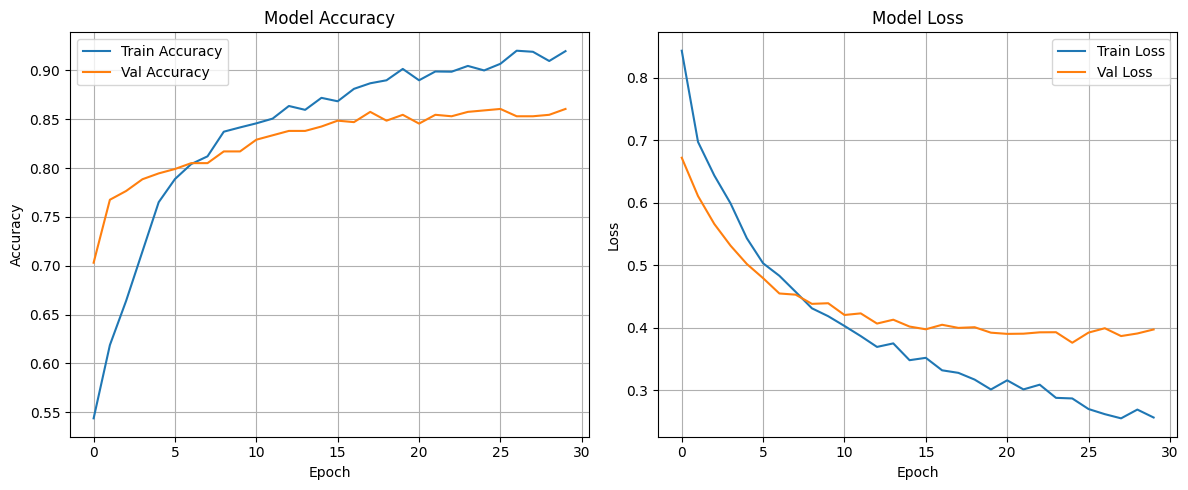


Final Train Accuracy: 91.97%


In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print Final Accuracy
print(f"\nFinal Train Accuracy: {history.history['accuracy'][-1]*100:.2f}%")

In [ ]:
from sklearn.metrics import precision_recall_curve

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


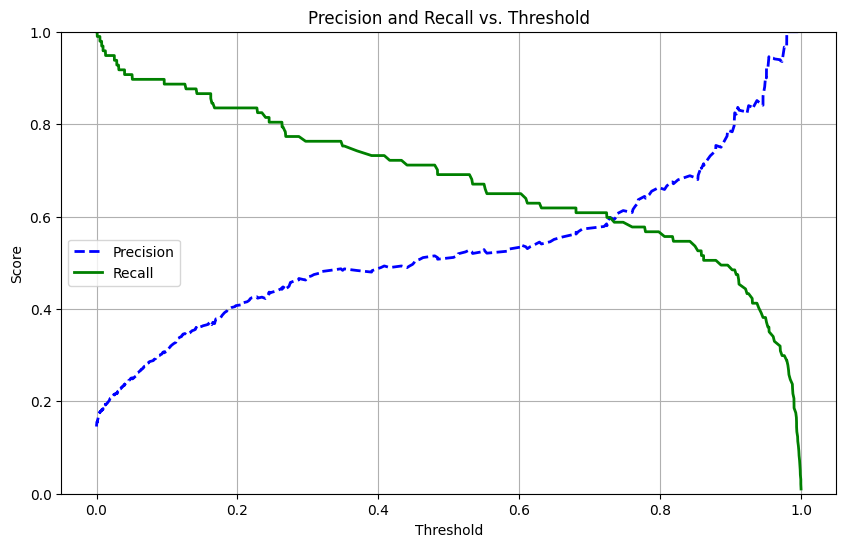

In [ ]:
y_pred_prob = model.predict(X_test)

# Calculate Precision & Recall for ALL thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Threshold")
plt.legend(loc="center left")
plt.grid(True)
plt.ylim([0, 1])
plt.show()